# Benchmarks: how fast, and *why*

SparseGF2 is a phase-free **sparse** stabilizer simulator. This notebook
measures its performance against [Stim](https://github.com/quantumlib/Stim)
(a state-of-the-art dense-tableau simulator) and plots the result, so the
claims in the README are reproducible end to end.

The thesis: a $Z$-measurement in SparseGF2 is a **sparse rank-update** whose
cost scales with the *weight* of the stabilizers it touches, not with $n$.
Measurements keep the tableau sparse (area-law), so the speedup over a dense
simulator **grows with both system size and measurement rate**, exactly the
regime measurement-induced-phase-transition (MIPT) studies live in.

## Contents
1. Setup
2. Scaling in $n$ (fixed measurement rate)
3. The measurement-rate crossover (fixed $n$)
4. The mechanism: stabilizer sparsity vs $p$
5. Graph topology has ~no effect on cost (at $O(n)$ depth)
6. Summary

## 1. Setup

Locate the benchmark scripts via the installed package (works from any working directory), import them, and warm up the Numba JIT so it doesn't pollute the timings.

In [2]:
%matplotlib inline
import sys, pathlib
import numpy as np
import matplotlib.pyplot as plt
import sparsegf2

ROOT = pathlib.Path(sparsegf2.__file__).resolve().parents[2]   # project root
sys.path.insert(0, str(ROOT / 'benchmarks'))
sys.path.insert(0, str(ROOT / 'benchmarks' / 'circuits'))
import benchmark_random_clifford as bench           # SparseGF2 vs Stim engine
import benchmark_topology_sparsity as topo          # circuits topology benchmark

if bench._numba_warmup:
    bench._numba_warmup()
print('Stim available:', bench._HAS_STIM, '| sparsegf2', sparsegf2.__version__)
plt.rcParams['figure.dpi'] = 110


Stim available: True | sparsegf2 2.0.0


## 2. Scaling in $n$

Random Clifford brickwork + $Z$-measurements at a fixed rate $p=0.25$, depth
$=n$. We time SparseGF2 (Numba) and Stim on the *same* circuits (best of 2
reps, to suppress noise). This is the headline result: where is the crossover,
and how does the advantage grow?

In [3]:
P = 0.25
ns = [32, 64, 128, 256, 512]
reps = 2
ours, stim = [], []
for n in ns:
    o_runs, s_runs = [], []
    for rep in range(reps):
        circ = bench.make_circuit(n, n, P, seed=rep)
        if bench._HAS_STIM:
            bench.precompile_stim_tableaux(circ)
        o_runs.append(bench.run_sparsegf2(circ))
        if bench._HAS_STIM:
            s_runs.append(bench.run_stim(circ))
    ours.append(min(o_runs))
    stim.append(min(s_runs) if s_runs else np.nan)
    print(f'n={n:4d}  ours={ours[-1]:7.3f}s  stim={stim[-1]:8.3f}s  '
          f'speedup={stim[-1]/ours[-1]:6.2f}x')
ns = np.array(ns); ours = np.array(ours); stim = np.array(stim)
speedup_n = stim / ours


n=  32  ours=  0.011s  stim=   0.003s  speedup=  0.24x
n=  64  ours=  0.008s  stim=   0.016s  speedup=  2.04x
n= 128  ours=  0.028s  stim=   0.100s  speedup=  3.52x
n= 256  ours=  0.115s  stim=   0.899s  speedup=  7.79x
n= 512  ours=  0.482s  stim=  10.690s  speedup= 22.19x


**Runtime vs $n$** (log-log). The two simulators have different slopes; the lines cross around $n\approx 64$, after which SparseGF2's shallower scaling pulls away.

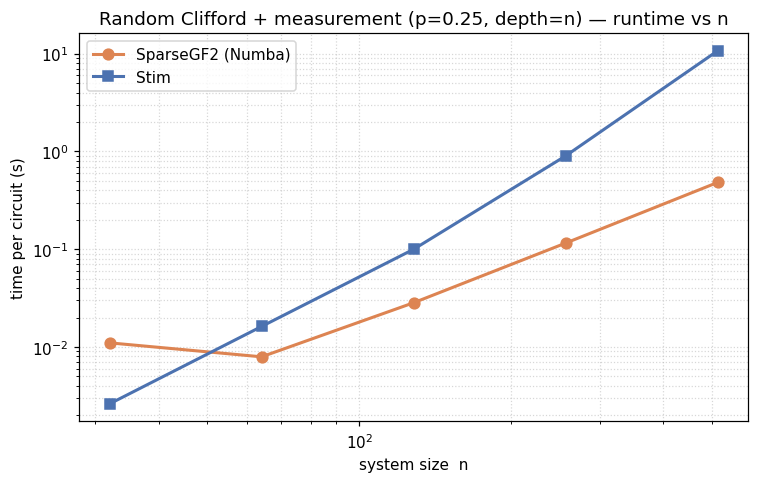

In [4]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.loglog(ns, ours, 'o-', color='#DD8452', label='SparseGF2 (Numba)', lw=2, ms=7)
ax.loglog(ns, stim, 's-', color='#4C72B0', label='Stim', lw=2, ms=7)
ax.set_xlabel('system size  n'); ax.set_ylabel('time per circuit (s)')
ax.set_title(f'Random Clifford + measurement (p={P}, depth=n): runtime vs n')
ax.grid(True, which='both', ls=':', alpha=0.5); ax.legend()
fig.tight_layout(); plt.show()


**Speedup vs $n$.** Below the dashed line Stim is faster; above it SparseGF2 is. The advantage grows roughly linearly in $n$ in this regime.

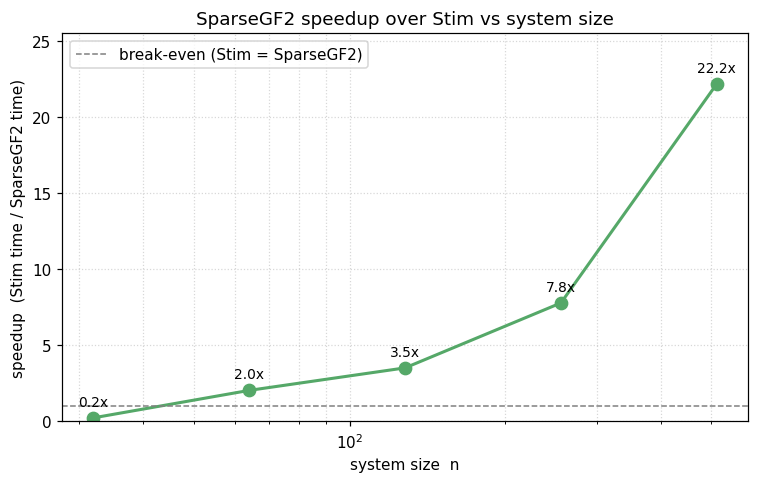

In [5]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.semilogx(ns, speedup_n, 'o-', color='#55A868', lw=2, ms=8)
ax.axhline(1.0, color='grey', ls='--', lw=1, label='break-even (Stim = SparseGF2)')
for x, y in zip(ns, speedup_n):
    ax.annotate(f'{y:.1f}x', (x, y), textcoords='offset points', xytext=(0, 8), ha='center', fontsize=9)
ax.set_xlabel('system size  n'); ax.set_ylabel('speedup  (Stim time / SparseGF2 time)')
ax.set_title('SparseGF2 speedup over Stim vs system size'); ax.set_ylim(0, max(speedup_n)*1.15)
ax.grid(True, which='both', ls=':', alpha=0.5); ax.legend()
fig.tight_layout(); plt.show()


## 3. The measurement-rate crossover

Now fix $n$ and sweep the measurement rate $p$. At $p=0$ (pure scrambling) the
state is **volume-law**: the tableau densifies and Stim wins. As $p$ rises the
monitored dynamics holds the state **area-law**: the tableau stays sparse and
SparseGF2 pulls ahead. The speedup is, quite literally, the measurement-induced
sparsity.

In [6]:
N = 256
# ps = [0.0, 0.01, 0.02, 0.03,0.04,0.05,0.06,0.07,0.08,0.09,0.10, 0.11,0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.20,0.25]
ps = np.arange(0.01, 0.20, 0.01)
ours_p, stim_p = [], []
for p in ps:
    o_runs, s_runs = [], []
    for rep in range(2):
        circ = bench.make_circuit(N, N, p, seed=rep)
        if bench._HAS_STIM:
            bench.precompile_stim_tableaux(circ)
        o_runs.append(bench.run_sparsegf2(circ))
        if bench._HAS_STIM:
            s_runs.append(bench.run_stim(circ))
    ours_p.append(min(o_runs)); stim_p.append(min(s_runs) if s_runs else np.nan)
    print(f'p={p:4.2f}  ours={ours_p[-1]:.3f}s  stim={stim_p[-1]:.3f}s  '
          f'speedup={stim_p[-1]/ours_p[-1]:5.2f}x')
ours_p = np.array(ours_p); stim_p = np.array(stim_p); speedup_p = stim_p / ours_p


p=0.01  ours=0.293s  stim=0.165s  speedup= 0.56x
p=0.02  ours=0.292s  stim=0.203s  speedup= 0.70x
p=0.03  ours=0.285s  stim=0.234s  speedup= 0.82x
p=0.04  ours=0.274s  stim=0.267s  speedup= 0.98x
p=0.05  ours=0.263s  stim=0.302s  speedup= 1.15x
p=0.06  ours=0.256s  stim=0.339s  speedup= 1.33x
p=0.07  ours=0.238s  stim=0.373s  speedup= 1.56x
p=0.08  ours=0.222s  stim=0.404s  speedup= 1.82x
p=0.09  ours=0.214s  stim=0.440s  speedup= 2.06x
p=0.10  ours=0.195s  stim=0.472s  speedup= 2.42x
p=0.11  ours=0.180s  stim=0.508s  speedup= 2.82x
p=0.12  ours=0.164s  stim=0.541s  speedup= 3.29x
p=0.13  ours=0.156s  stim=0.570s  speedup= 3.66x
p=0.14  ours=0.145s  stim=0.634s  speedup= 4.37x
p=0.15  ours=0.171s  stim=0.688s  speedup= 4.03x
p=0.16  ours=0.135s  stim=0.694s  speedup= 5.16x
p=0.17  ours=0.128s  stim=0.724s  speedup= 5.67x
p=0.18  ours=0.124s  stim=0.771s  speedup= 6.21x
p=0.19  ours=0.119s  stim=0.758s  speedup= 6.36x


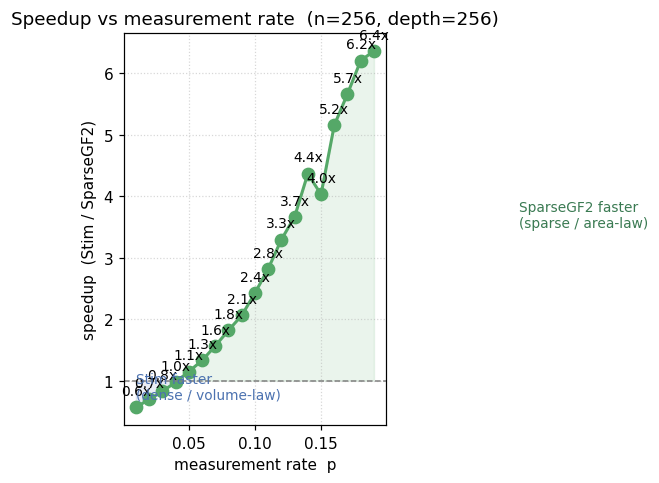

In [7]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(ps, speedup_p, 'o-', color='#55A868', lw=2, ms=8)
ax.axhline(1.0, color='grey', ls='--', lw=1)
ax.fill_between(ps, 1.0, speedup_p, where=(speedup_p >= 1.0), color='#55A868', alpha=0.12)
ax.fill_between(ps, speedup_p, 1.0, where=(speedup_p < 1.0), color='#4C72B0', alpha=0.12)
for x, y in zip(ps, speedup_p):
    ax.annotate(f'{y:.1f}x', (x, y), textcoords='offset points', xytext=(0, 8), ha='center', fontsize=9)
ax.text(0.01, 0.7, 'Stim faster\n(dense / volume-law)', fontsize=9, color='#4C72B0')
ax.text(0.30, max(speedup_p)*0.55, 'SparseGF2 faster\n(sparse / area-law)', fontsize=9, color='#3a7a52')
ax.set_xlabel('measurement rate  p'); ax.set_ylabel('speedup  (Stim / SparseGF2)')
ax.set_title(f'Speedup vs measurement rate  (n={N}, depth={N})')
ax.grid(True, ls=':', alpha=0.5)
fig.tight_layout(); plt.show()


## 4. The mechanism: stabilizer sparsity vs $p$

Why does more measurement mean more speed? Because the cost of a sparse
measurement scales with the **stabilizer weight** (non-identity Paulis per
generator), and measurements keep that weight small. We measure it directly on
a nearest-neighbour brickwork circuit as $p$ varies (reusing the circuits-side
benchmark), and overlay it on the speedup curve: as the average weight falls,
the speedup rises.

p=0.01  avg stabilizer weight = 150.45
p=0.02  avg stabilizer weight = 132.96
p=0.03  avg stabilizer weight = 116.63
p=0.04  avg stabilizer weight = 102.85
p=0.05  avg stabilizer weight =  88.59
p=0.06  avg stabilizer weight =  79.72
p=0.07  avg stabilizer weight =  74.14
p=0.08  avg stabilizer weight =  64.52
p=0.09  avg stabilizer weight =  54.15
p=0.10  avg stabilizer weight =  46.11
p=0.11  avg stabilizer weight =  39.10
p=0.12  avg stabilizer weight =  33.69
p=0.13  avg stabilizer weight =  24.25
p=0.14  avg stabilizer weight =  21.18
p=0.15  avg stabilizer weight =  16.45
p=0.16  avg stabilizer weight =   9.82
p=0.17  avg stabilizer weight =   7.44
p=0.18  avg stabilizer weight =   6.05
p=0.19  avg stabilizer weight =   4.73


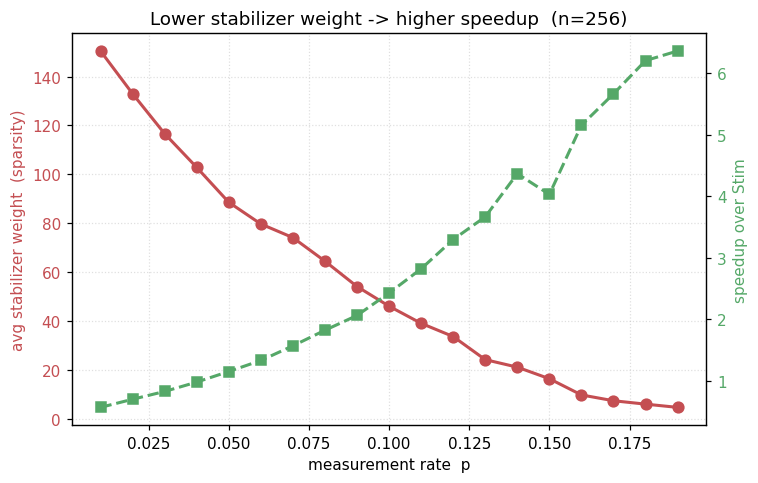

In [8]:
topo._warmup()
weights = []
for p in ps:
    _, avg_w, _ = topo.bench(N, 'cycle', p, depth_factor=4, seed=0)
    weights.append(avg_w)
    print(f'p={p:4.2f}  avg stabilizer weight = {avg_w:6.2f}')
weights = np.array(weights)

fig, ax1 = plt.subplots(figsize=(7, 4.5))
c1, c2 = '#C44E52', '#55A868'
ax1.plot(ps, weights, 'o-', color=c1, lw=2, ms=7)
ax1.set_xlabel('measurement rate  p')
ax1.set_ylabel('avg stabilizer weight  (sparsity)', color=c1)
ax1.tick_params(axis='y', labelcolor=c1)
ax2 = ax1.twinx()
ax2.plot(ps, speedup_p, 's--', color=c2, lw=2, ms=7)
ax2.set_ylabel('speedup over Stim', color=c2); ax2.tick_params(axis='y', labelcolor=c2)
ax1.set_title(f'Lower stabilizer weight -> higher speedup  (n={N})')
ax1.grid(True, ls=':', alpha=0.4)
fig.tight_layout(); plt.show()


## 5. Graph topology has ~no effect on cost (at $O(n)$ depth)

A natural guess is that nearest-neighbour (`cycle`) circuits simulate faster
than all-to-all (`complete`) ones, because local gates keep stabilizer
supports short. We measured it, and at the $O(n)$ depths we run, the tableau
*saturates* either way, so topology barely changes the runtime (it changes the
physics, not the cost).

n=  32  cycle=0.0133s  complete=0.0109s  ratio=0.82
n=  64  cycle=0.0395s  complete=0.0278s  ratio=0.70
n= 128  cycle=0.1131s  complete=0.1287s  ratio=1.14


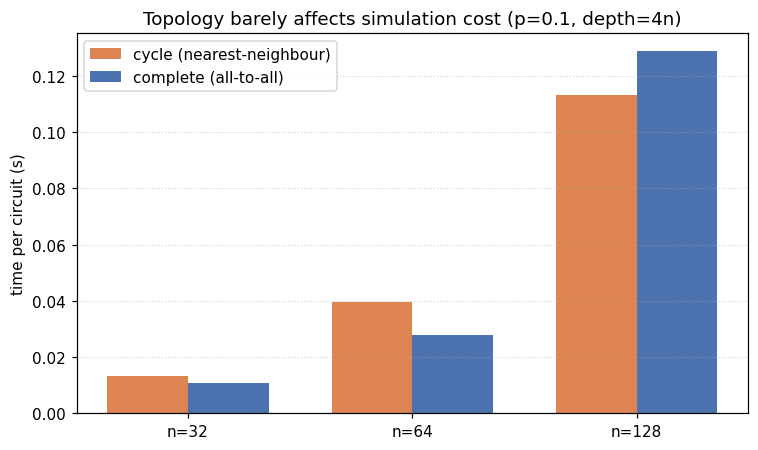

In [9]:
sizes = [32, 64, 128]
t_cycle, t_complete = [], []
for n in sizes:
    tc, _, _ = topo.bench(n, 'cycle', 0.2, depth_factor=4, seed=0)
    tk, _, _ = topo.bench(n, 'complete', 0.2, depth_factor=4, seed=0)
    t_cycle.append(tc); t_complete.append(tk)
    print(f'n={n:4d}  cycle={tc:.4f}s  complete={tk:.4f}s  ratio={tk/tc:.2f}')

x = np.arange(len(sizes)); w = 0.36
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.bar(x - w/2, t_cycle, w, label='cycle (nearest-neighbour)', color='#DD8452')
ax.bar(x + w/2, t_complete, w, label='complete (all-to-all)', color='#4C72B0')
ax.set_xticks(x); ax.set_xticklabels([f'n={n}' for n in sizes])
ax.set_ylabel('time per circuit (s)'); ax.set_title('Topology barely affects simulation cost (p=0.1, depth=4n)')
ax.legend(); ax.grid(True, axis='y', ls=':', alpha=0.5)
fig.tight_layout(); plt.show()


## 6. Summary

- **Scaling:** SparseGF2 overtakes Stim around $n\approx 64$ and the advantage
  grows with $n$ (≈3× at 128, ≈8× at 256, ≈20× at 512 at $p=0.25$).
- **Measurement rate:** the speedup *is* the measurement-induced sparsity,
  Stim wins at $p=0$ (volume-law), SparseGF2 wins by an increasing margin as
  $p$ rises (area-law).
- **Mechanism:** lower stabilizer weight ⇒ cheaper sparse measurements ⇒
  higher speedup.
- **Topology:** at $O(n)$ depth it's a physics knob, not a speed knob.

So for the **large-$n$, strongly-monitored** circuits MIPT studies need,
SparseGF2 is the fast path. Reproduce any of this directly:

```sh
.venv/bin/python benchmarks/benchmark_random_clifford.py --ns 64 128 256 512 --p 0.25
.venv/bin/python benchmarks/benchmark_measurement_rate.py --n 192
```